importing libery


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Data set Download

In [1]:
!wget https://raw.githubusercontent.com/codebasics/deep-learning-keras-tf-tutorial/master/7_nn_from_scratch/insurance_data.csv

--2026-04-21 04:33:54--  https://raw.githubusercontent.com/codebasics/deep-learning-keras-tf-tutorial/master/7_nn_from_scratch/insurance_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231 [text/plain]
Saving to: ‘insurance_data.csv’

insurance_data.csv  100%[===================>]     231  --.-KB/s    in 0s      

2026-04-21 04:33:54 (3.13 MB/s) - ‘insurance_data.csv’ saved [231/231]



In [4]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,affordibility,bought_insurance
0,22,1,0
1,25,0,0
2,47,1,1
3,52,0,0
4,46,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               28 non-null     int64
 1   affordibility     28 non-null     int64
 2   bought_insurance  28 non-null     int64
dtypes: int64(3)
memory usage: 804.0 bytes


In [6]:
df['age']=df['age']/df['age'].max()

In [7]:
X = df.drop('bought_insurance', axis=1).values
y = df['bought_insurance'].values

Sigmoid activation function

$\sigma(x) = \frac{1}{1 + e^{-x}}$

In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

Standar Deviation

$SDT = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$

In [9]:
def standardize(x):
  return (x - x.mean()) / x.std()

Log Loss Function

$L = - \frac{1}{n} \sum_{i=1}^{n}\left[ y_i \log(p_i) + (1 - y_i)\log(1 - p_i) \right]$

In [10]:
def Log_loss(y_test,y_predicted):
  epsilon=1e-15
  y_predicted_new = np.maximum(y_predicted,epsilon)
  y_predicted_new = np.minimum(y_predicted_new,1-epsilon)
  return -np.mean(y_test*np.log(y_predicted_new)+(1-y_test)*np.log(1-y_predicted_new))

Adam Gradient Descent function

$w = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)x_i$

$b = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)$

$m_w = \beta_1 m_w + (1 - \beta_1) w$

$m_b = \beta_1 m_b + (1 - \beta_1) b$

$v_w = \beta_2 v_w + (1 - \beta_2) w^2$

$v_b = \beta_2 v_b + (1 - \beta_2) b^2$

$\hat{m}_w = \frac{m_w}{1 - \beta_1^t}$

$\hat{m}_b = \frac{m_b}{1 - \beta_1^t}$

$\hat{v}_w = \frac{v_w}{1 - \beta_2^t}$

$\hat{v}_b = \frac{v_b}{1 - \beta_2^t}$

$weight = weight - \frac{learning\ rate \times \hat{m}_w}{\sqrt{\hat{v}_w} + \epsilon}$

$bias = bias - \frac{learning\ rate \times \hat{m}_b}{\sqrt{\hat{v}_b} + \epsilon}$

In [143]:
def ADAM(X, y, epochs=1000, lr=0.01, beta1=0.9, beta2=0.999):

    # Convert to numpy
    X = np.array(X)
    y = np.array(y)

    # Standardize (column-wise using your function)
    for i in range(X.shape[1]):
        X[:, i] = standardize(X[:, i])

    n_samples, n_features = X.shape

    # Initialize
    weights = np.zeros(n_features)
    bias = 0

    # 1st moment (Momentum)
    m_w = np.zeros(n_features)
    m_b = 0

    # 2nd moment (RMSprop)
    v_w = np.zeros(n_features)
    v_b = 0

    epsilon = 1e-8

    losses, accuracies, epoch_list = [], [], []

    for t in range(1, epochs + 1):

        # Forward
        linear = np.dot(X, weights) + bias
        y_pred = sigmoid(linear)

        # Loss
        loss = Log_loss(y, y_pred)

        # Gradients
        error = y_pred - y
        dw = np.dot(X.T, error) / n_samples
        db = np.mean(error)

        # Momentum (1st moment)
        m_w = beta1 * m_w + (1 - beta1) * dw
        m_b = beta1 * m_b + (1 - beta1) * db

        # RMSprop (2nd moment)
        v_w = beta2 * v_w + (1 - beta2) * (dw ** 2)
        v_b = beta2 * v_b + (1 - beta2) * (db ** 2)

        # Bias correction
        m_w_hat = m_w / (1 - beta1**t)
        m_b_hat = m_b / (1 - beta1**t)

        v_w_hat = v_w / (1 - beta2**t)
        v_b_hat = v_b / (1 - beta2**t)

        # Update
        weights -= lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)
        bias -= lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

        # Accuracy
        accuracy = np.mean((y_pred > 0.5) == y)

        losses.append(loss)
        accuracies.append(accuracy)
        epoch_list.append(t)

        if t % 10 == 0:
            print(f"Epoch {t} | Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

    return weights, bias, losses, accuracies, epoch_list

In [150]:
weights, bias, losses, accuracies, epochs = ADAM(X, y, epochs=100, lr=0.1)

Epoch 10 | Loss: 0.4238 | Accuracy: 0.8929
Epoch 20 | Loss: 0.3639 | Accuracy: 0.9286
Epoch 30 | Loss: 0.3562 | Accuracy: 0.8571
Epoch 40 | Loss: 0.3580 | Accuracy: 0.8571
Epoch 50 | Loss: 0.3573 | Accuracy: 0.8929
Epoch 60 | Loss: 0.3566 | Accuracy: 0.8929
Epoch 70 | Loss: 0.3561 | Accuracy: 0.8929
Epoch 80 | Loss: 0.3561 | Accuracy: 0.8929
Epoch 90 | Loss: 0.3561 | Accuracy: 0.8929
Epoch 100 | Loss: 0.3561 | Accuracy: 0.8929


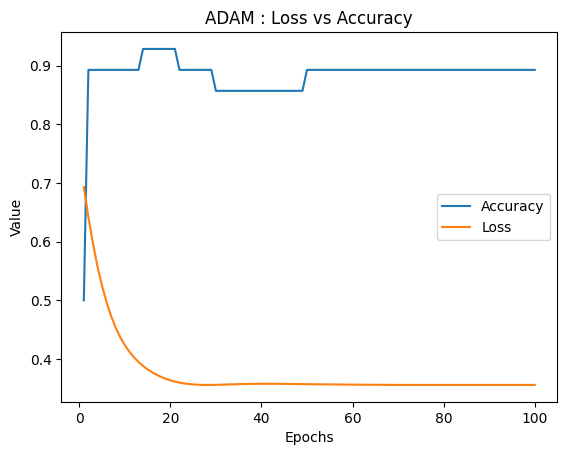

In [151]:
plt.plot(epochs, accuracies, label='Accuracy')
plt.plot(epochs, losses, label='Loss')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('ADAM : Loss vs Accuracy')
plt.legend()
plt.show()